# How to Make Your AI Agent Look Like a Pro — Using Agent Skills

**Use-case : Customer Clustering**
<p>-<b>Agent without Skills vs Agent WITH Skills</b>
<p>- <b>How to create a skill file</b>
<p>- <b>Building Langgraph Agent for clustering without skills</b>
<p>- <b>Injecting Clustering Skills</b>
<p>- <b>Comparing the results</b>
<p><p><b>The Agent with skills has a more professional looking analysis and output !</b>
    

# LangGraph Agent Skills — Data Analysis Demo

## Without Skill vs. With Skill: Customer Clustering

This notebook demonstrates how an **agent skill file** (a Markdown document encoding domain expertise)
dramatically improves the quality of a LangGraph data analysis agent.

| | Agent WITHOUT Skill | Agent WITH Skill |
|---|---|---|
| K selection | Arbitrary / hardcoded | Elbow + Silhouette search |
| Preprocessing | May skip normalization | StandardScaler always applied |
| Visualization | Single scatter plot | 4-panel dashboard |
| Interpretation | Generic | Named segments + business actions |

**Dataset:** Synthetic Mall Customer data (Age, Annual Income, Spending Score)  
**LLM:** OpenAI GPT-4o  
**Framework:** LangGraph + LangChain

In [ ]:
# Install dependencies
!pip install -q langgraph langchain langchain-openai scikit-learn pandas matplotlib seaborn

In [1]:
%matplotlib inline
import os
import getpass
import io
from contextlib import redirect_stdout
from typing import TypedDict, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from IPython.display import Image, display, Markdown
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# --- API Key ---
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

llm = ChatOpenAI(model="gpt-4o", temperature=0)
print("Setup complete!")

/Users/pranay.dave/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pranay.dave/Library/Python/3.9/lib/python/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Enter your OpenAI API key:  ········


Setup complete!


---
## Dataset: Synthetic Mall Customer Data

We create a synthetic dataset with **5 natural customer segments** that the agent should discover.
The ground-truth clusters are hidden — the agents must find them.

In [2]:
np.random.seed(42)

def create_customer_data():
    # (n, age_mean, age_std, income_mean, income_std, spending_mean, spending_std)
    cluster_configs = [
        (40, 25, 5,  30,  8,  82, 8),   # Young, low income, high spending
        (40, 46, 7, 100, 12,  15, 8),   # Middle-aged, high income, low spending
        (40, 36, 6,  90, 10,  83, 8),   # Middle-aged, high income, high spending
        (40, 52, 9,  25,  8,  18, 8),   # Older, low income, low spending
        (40, 30, 7,  55, 10,  50, 12),  # Young, medium income, medium spending
    ]
    dfs = []
    for n, am, as_, im, is_, sm, ss in cluster_configs:
        dfs.append(pd.DataFrame({
            'Age':                     np.clip(np.random.normal(am, as_, n), 18, 70).astype(int),
            'Annual Income (k$)':      np.clip(np.random.normal(im, is_, n), 10, 150).astype(int),
            'Spending Score (1-100)':  np.clip(np.random.normal(sm, ss, n), 1, 100).astype(int),
        }))
    df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    df.insert(0, 'CustomerID', range(1, len(df) + 1))
    return df

df = create_customer_data()
print(f"Dataset shape: {df.shape}")
display(df.head(8))
display(df.describe())

Dataset shape: (200, 4)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,33,83,81
1,2,22,37,70
2,3,21,32,66
3,4,50,11,42
4,5,52,25,13
5,6,38,90,74
6,7,48,81,20
7,8,29,61,50


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,37.100000,59.605000,49.235000
std,57.879185,12.880588,32.481289,30.461604
min,1.000000,18.000000,10.000000,1.000000
25%,50.750000,26.000000,30.000000,19.000000
50%,100.500000,36.000000,51.500000,51.000000
75%,150.250000,47.000000,91.000000,80.000000
max,200.000000,70.000000,132.000000,100.000000


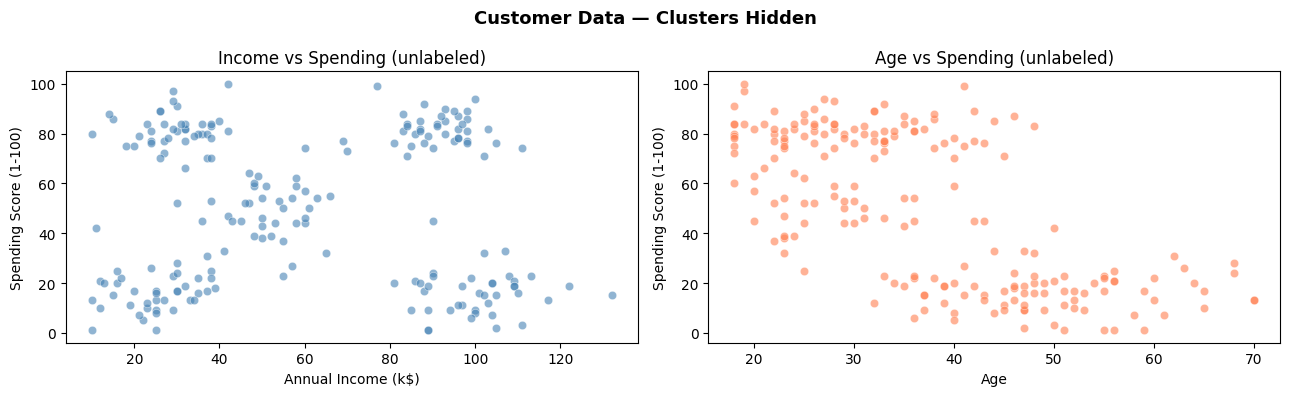

Can you spot the 5 clusters by eye?


In [3]:
# Quick exploratory scatter — clusters are NOT labeled yet
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.4)
axes[0].set(xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)', title='Income vs Spending (unlabeled)')

axes[1].scatter(df['Age'], df['Spending Score (1-100)'], alpha=0.6, color='coral', edgecolors='white', linewidth=0.4)
axes[1].set(xlabel='Age', ylabel='Spending Score (1-100)', title='Age vs Spending (unlabeled)')

plt.suptitle('Customer Data — Clusters Hidden', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Can you spot the 5 clusters by eye?")

In [4]:
# Helper: build a data description string for the LLM prompt
def get_data_description(df):
    return (
        f"Dataset: Mall Customer Data\n"
        f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n"
        f"Columns: {list(df.columns)}\n\n"
        f"Sample (first 3 rows):\n{df.head(3).to_string()}\n\n"
        f"Statistics:\n{df.describe().to_string()}"
    )

# Helper: extract code block from LLM response
def extract_code(text):
    text = text.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        text = "\n".join(lines[1:-1] if lines[-1] == "```" else lines[1:])
    return text

# Helper: execute generated code in a sandboxed namespace
def run_generated_code(code, df):
    namespace = {
        'df': df.copy(),
        'pd': pd, 'np': np, 'plt': plt, 'sns': sns,
        'KMeans': KMeans,
        'StandardScaler': StandardScaler,
        'silhouette_score': silhouette_score,
    }
    buf = io.StringIO()
    try:
        with redirect_stdout(buf):
            exec(code, namespace)
    except Exception as e:
        buf.write(f"\nExecution error: {e}")
    return buf.getvalue()

print("Helpers ready.")

Helpers ready.


---
## Part 1 — Data Analysis Agent WITHOUT a Skill File

This agent has **no domain knowledge**. It asks the LLM generically to produce clustering code.

```
START → generate_code → execute_code → interpret → END
```

In [5]:
# ── State ──────────────────────────────────────────────────────────────────
class BasicState(TypedDict):
    query:            str
    data_description: str
    generated_code:   str
    execution_output: str
    interpretation:   str

# ── Nodes ──────────────────────────────────────────────────────────────────
def basic_generate_code(state: BasicState) -> dict:
    """Ask the LLM for clustering code — no skill context."""
    messages = [
        SystemMessage(content=(
            "You are a data analysis assistant.\n"
            "Generate Python code to perform clustering analysis on the provided dataset.\n"
            "The variable `df` is already loaded. Import any libraries you need inside the code.\n"
            "Create a visualization and print the results.\n"
            "Return ONLY the Python code — no markdown fences, no explanations."
        )),
        HumanMessage(content=f"Query: {state['query']}\n\nData:\n{state['data_description']}")
    ]
    response = llm.invoke(messages)
    code = extract_code(response.content)
    print("[basic] Code generated")
    return {"generated_code": code}


def execute_code_node(state) -> dict:
    """Execute the generated code and capture printed output."""
    output = run_generated_code(state["generated_code"], df)
    print("[node] Code executed")
    return {"execution_output": output}


def basic_interpret(state: BasicState) -> dict:
    """Ask the LLM to interpret the clustering results."""
    messages = [
        SystemMessage(content="You are a data analyst. Interpret the clustering output in 4-5 sentences. Focus on patterns."),
        HumanMessage(content=(
            f"Query: {state['query']}\n\n"
            f"Printed output from the code:\n{state['execution_output'][:3000]}"
        ))
    ]
    response = llm.invoke(messages)
    print("[basic] Interpretation done")
    return {"interpretation": response.content}


print("Basic agent nodes defined.")

Basic agent nodes defined.


In [6]:
# ── Build graph ─────────────────────────────────────────────────────────────
basic_builder = StateGraph(BasicState)
basic_builder.add_node("generate_code", basic_generate_code)
basic_builder.add_node("execute_code",  execute_code_node)
basic_builder.add_node("interpret",     basic_interpret)

basic_builder.add_edge(START,           "generate_code")
basic_builder.add_edge("generate_code", "execute_code")
basic_builder.add_edge("execute_code",  "interpret")
basic_builder.add_edge("interpret",     END)

basic_graph = basic_builder.compile()
print("Basic graph compiled.")

Basic graph compiled.


Agent WITHOUT Skill — Graph Structure:


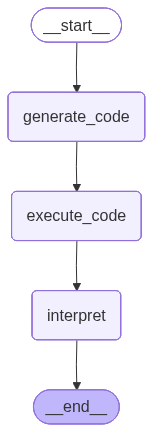

In [7]:
# ── Visualize graph ─────────────────────────────────────────────────────────
print("Agent WITHOUT Skill — Graph Structure:")
try:
    display(Image(basic_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(basic_graph.get_graph().draw_mermaid())

RUNNING: Agent WITHOUT Skill
[basic] Code generated


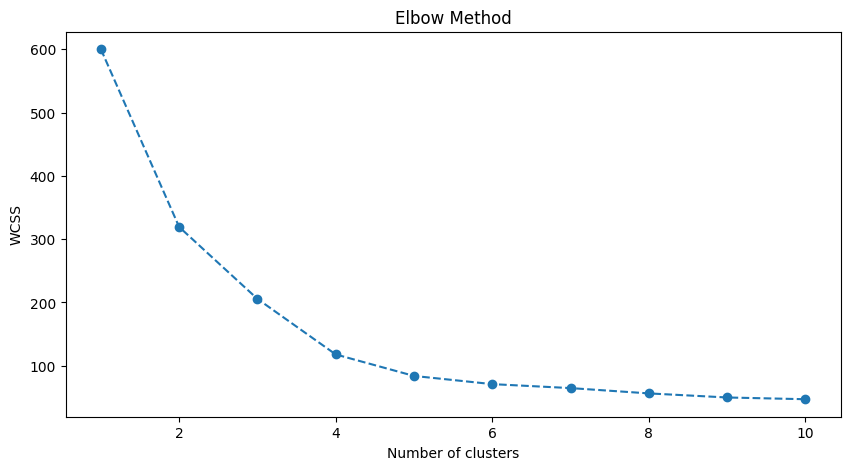

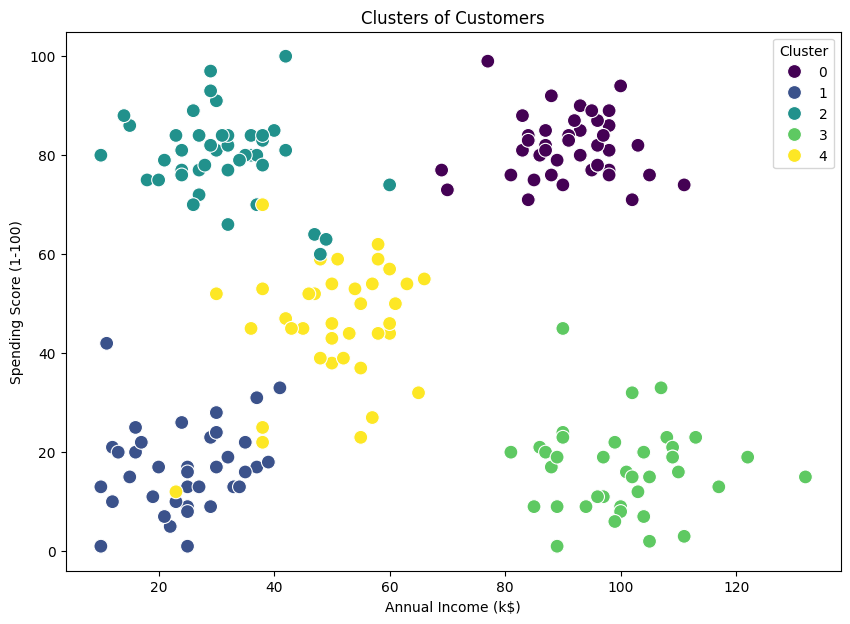

[node] Code executed
[basic] Interpretation done

INTERPRETATION (basic agent):
The clustering analysis on the customer dataset has resulted in five distinct customer segments, each characterized by different patterns in the three dimensions analyzed. The first cluster, with centers at approximately (34.85, 91.15, 81.61), suggests a group of relatively young customers with high engagement and high spending. The second cluster, centered around (54.39, 24.71, 16.89), indicates an older demographic with low engagement and low spending. The third cluster, with centers at (23.36, 31.25, 80.09), represents younger customers with moderate engagement but high spending. The fourth cluster, centered at (45.3, 100.3, 16.18), highlights middle-aged customers with very high engagement but low spending. Lastly, the fifth cluster, with centers at (29.30, 50.22, 45.62), captures a segment of younger customers with moderate engagement and moderate spending. These patterns can help in tailoring marketin

In [8]:
# ── Run agent ───────────────────────────────────────────────────────────────
print("=" * 60)
print("RUNNING: Agent WITHOUT Skill")
print("=" * 60)

result_basic = basic_graph.invoke({
    "query":            "Perform clustering analysis on this customer dataset to identify customer segments",
    "data_description": get_data_description(df),
    "generated_code":   "",
    "execution_output": "",
    "interpretation":   "",
})

print("\n" + "=" * 60)
print("INTERPRETATION (basic agent):")
print("=" * 60)
print(result_basic["interpretation"])

---
## Part 2 — The Clustering Skill File

The skill file `clustering_skill.md` encodes **domain expertise** as a Markdown document:
- Which algorithm to use and why
- How to find optimal K (Elbow + Silhouette)
- Visualization layout (4-panel)
- Business segment naming conventions
- A complete code template to follow

The skill agent loads this file at runtime and injects it into the system prompt.

In [9]:
with open("clustering_skill.md", "r") as f:
    skill_content = f.read()

display(Markdown(skill_content))

# Clustering Analysis Skill

## When to Use This Skill
Apply this skill for cluster analysis on tabular customer or behavioral data, especially for:
- Customer segmentation
- Market segmentation
- Pattern discovery in multi-dimensional behavioral data

---

## Step 1: Data Preprocessing
Always standardize features before clustering — K-Means is sensitive to feature scale.

```python
from sklearn.preprocessing import StandardScaler
features = ['Annual Income (k$)', 'Spending Score (1-100)', 'Age']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
```

Never use ID columns as features.

---

## Step 2: Find Optimal Number of Clusters
Always test K from 2 to 8 using BOTH methods before fitting a final model.

**Elbow Method:** Plot inertia (within-cluster sum of squares) vs K. The "elbow" is where
the rate of decrease sharply slows — this is your candidate K.

**Silhouette Score:** Measures how similar each point is to its own cluster vs. other clusters.
Range: -1 to 1. Score > 0.5 = well-separated clusters. Choose the K with the highest silhouette score.

**Decision rule:** Choose K where the elbow is visible AND silhouette score is at or near its peak.

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
```

---

## Step 3: Fit the Final Model

```python
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X)
```

---

## Step 4: Visualization — Always Use a 4-Panel Layout

Create a `fig, axes = plt.subplots(2, 2, figsize=(14, 10))` figure:

| Position | Plot | Details |
|----------|------|---------|
| `axes[0,0]` | Elbow Curve | Inertia vs K; mark chosen K with a red dashed vertical line |
| `axes[0,1]` | Silhouette Scores | Score vs K; mark chosen K with a red dashed vertical line |
| `axes[1,0]` | Scatter Plot | Annual Income vs Spending Score, colored by cluster; mark centroids as gold stars |
| `axes[1,1]` | Cluster Profiles | Horizontal bar chart of mean feature values per cluster (normalized) |

Add a main `fig.suptitle` and call `plt.tight_layout()` before `plt.show()`.

---

## Step 5: Business Segment Naming
After clustering, compute per-cluster means and assign business labels:

| Income Level | Spending Level | Segment Name | Strategy |
|-------------|---------------|--------------|----------|
| High (>70k) | High (>60) | **Premium Customers** | Loyalty programs, exclusive offers |
| High (>70k) | Low (<40) | **Cautious High-Earners** | Targeted promotions, trust-building |
| Low (<45k) | High (>60) | **Young Spenders** | Instalment plans, trendy products |
| Low (<45k) | Low (<40) | **Budget Conscious** | Discounts, value bundles |
| Medium | Medium | **Balanced Customers** | General marketing, cross-sell |

---

## Step 6: Required Printed Output
Always print the following after clustering:

1. `"Optimal K = X  |  Silhouette Score = Y.YY"`
2. A cluster summary table: Cluster ID, Size, Mean Age, Mean Income, Mean Spending, Segment Name
3. One actionable recommendation per segment

---

## Step 7: Complete Code Template

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Preprocess
features = ['Annual Income (k$)', 'Spending Score (1-100)', 'Age']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

# 2. Find optimal K
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Optimal K = {best_k}  |  Silhouette Score = {max(silhouettes):.2f}")

# 3. Fit final model
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X)

# 4. Four-panel visualization
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Customer Segmentation — K-Means (K={best_k})', fontsize=16, fontweight='bold')

axes[0, 0].plot(list(K_range), inertias, 'bo-')
axes[0, 0].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
axes[0, 0].set(title='Elbow Curve', xlabel='K', ylabel='Inertia')
axes[0, 0].legend()

axes[0, 1].plot(list(K_range), silhouettes, 'go-')
axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
axes[0, 1].set(title='Silhouette Scores', xlabel='K', ylabel='Silhouette Score')
axes[0, 1].legend()

for cluster_id in range(best_k):
    mask = df['Cluster'] == cluster_id
    axes[1, 0].scatter(df.loc[mask, 'Annual Income (k$)'],
                       df.loc[mask, 'Spending Score (1-100)'],
                       c=[colors[cluster_id]], label=f'Cluster {cluster_id}', alpha=0.7)
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
axes[1, 0].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                   c='gold', marker='*', s=300, zorder=5, label='Centroids')
axes[1, 0].set(title='Income vs Spending by Cluster',
               xlabel='Annual Income (k$)', ylabel='Spending Score')
axes[1, 0].legend()

cluster_means = df.groupby('Cluster')[features].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_means_norm.T.plot(kind='barh', ax=axes[1, 1], colormap='tab10')
axes[1, 1].set(title='Cluster Profiles (Normalized)', xlabel='Normalized Mean Value')

plt.tight_layout()
plt.show()

# 5. Print cluster summary with business labels
def assign_label(row):
    inc, spend = row['Annual Income (k$)'], row['Spending Score (1-100)']
    if inc > 70 and spend > 60: return 'Premium Customers'
    if inc > 70 and spend < 40: return 'Cautious High-Earners'
    if inc < 45 and spend > 60: return 'Young Spenders'
    if inc < 45 and spend < 40: return 'Budget Conscious'
    return 'Balanced Customers'

summary = cluster_means.copy()
summary['Size'] = df['Cluster'].value_counts().sort_index()
summary['Segment'] = summary.apply(assign_label, axis=1)
print("\nCluster Summary:")
print(summary.to_string())
```


---
## Part 3 — Data Analysis Agent WITH Skill File

The skill agent adds a **`load_skill`** node at the start of the graph.
This node reads `clustering_skill.md` and injects its content into the code-generation prompt.

```
START → load_skill → generate_code → execute_code → interpret → END
```

Everything else stays the same — only the **system prompt for `generate_code` changes**.

In [10]:
# ── State ──────────────────────────────────────────────────────────────────
class SkillState(TypedDict):
    query:            str
    data_description: str
    skill_content:    str   # <-- injected from clustering_skill.md
    generated_code:   str
    execution_output: str
    interpretation:   str

# ── Nodes ──────────────────────────────────────────────────────────────────
def load_skill(state: SkillState) -> dict:
    """Load the clustering skill file and inject into agent state."""
    with open("clustering_skill.md", "r") as f:
        skill = f.read()
    print("[skill] Loaded: clustering_skill.md")
    return {"skill_content": skill}


def skill_generate_code(state: SkillState) -> dict:
    """Ask the LLM for clustering code — skill guidelines injected into system prompt."""
    messages = [
        SystemMessage(content=(
            "You are a data analysis expert with deep clustering knowledge.\n\n"
            "=== CLUSTERING SKILL GUIDELINES ===\n"
            f"{state['skill_content']}\n"
            "=== END OF GUIDELINES ===\n\n"
            "Follow these guidelines strictly to produce high-quality clustering code.\n"
            "The variable `df` is already loaded. Import any libraries inside the code.\n"
            "Return ONLY the Python code — no markdown fences, no explanations."
        )),
        HumanMessage(content=f"Query: {state['query']}\n\nData:\n{state['data_description']}")
    ]
    response = llm.invoke(messages)
    code = extract_code(response.content)
    print("[skill] Code generated")
    return {"generated_code": code}


def skill_interpret(state: SkillState) -> dict:
    """Interpret results using skill context — names segments and gives actions."""
    messages = [
        SystemMessage(content=(
            "You are a customer analytics expert.\n"
            "Interpret the clustering results using business terminology.\n"
            "Name each segment clearly and provide one actionable recommendation per segment.\n"
            "Use the segment naming conventions from these guidelines:\n"
            f"{state['skill_content'][state['skill_content'].find('Business Segment'):][:800]}"
        )),
        HumanMessage(content=(
            f"Query: {state['query']}\n\n"
            f"Printed output from the code:\n{state['execution_output'][:3000]}"
        ))
    ]
    response = llm.invoke(messages)
    print("[skill] Interpretation done")
    return {"interpretation": response.content}


print("Skill agent nodes defined.")

Skill agent nodes defined.


In [11]:
# ── Build graph ─────────────────────────────────────────────────────────────
skill_builder = StateGraph(SkillState)
skill_builder.add_node("load_skill",    load_skill)
skill_builder.add_node("generate_code", skill_generate_code)
skill_builder.add_node("execute_code",  execute_code_node)
skill_builder.add_node("interpret",     skill_interpret)

skill_builder.add_edge(START,           "load_skill")
skill_builder.add_edge("load_skill",    "generate_code")
skill_builder.add_edge("generate_code", "execute_code")
skill_builder.add_edge("execute_code",  "interpret")
skill_builder.add_edge("interpret",     END)

skill_graph = skill_builder.compile()
print("Skill graph compiled.")

Skill graph compiled.


Agent WITH Skill — Graph Structure:


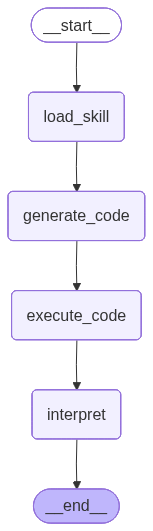

In [12]:
# ── Visualize graph ─────────────────────────────────────────────────────────
print("Agent WITH Skill — Graph Structure:")
try:
    display(Image(skill_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(skill_graph.get_graph().draw_mermaid())

RUNNING: Agent WITH Skill
[skill] Loaded: clustering_skill.md
[skill] Code generated


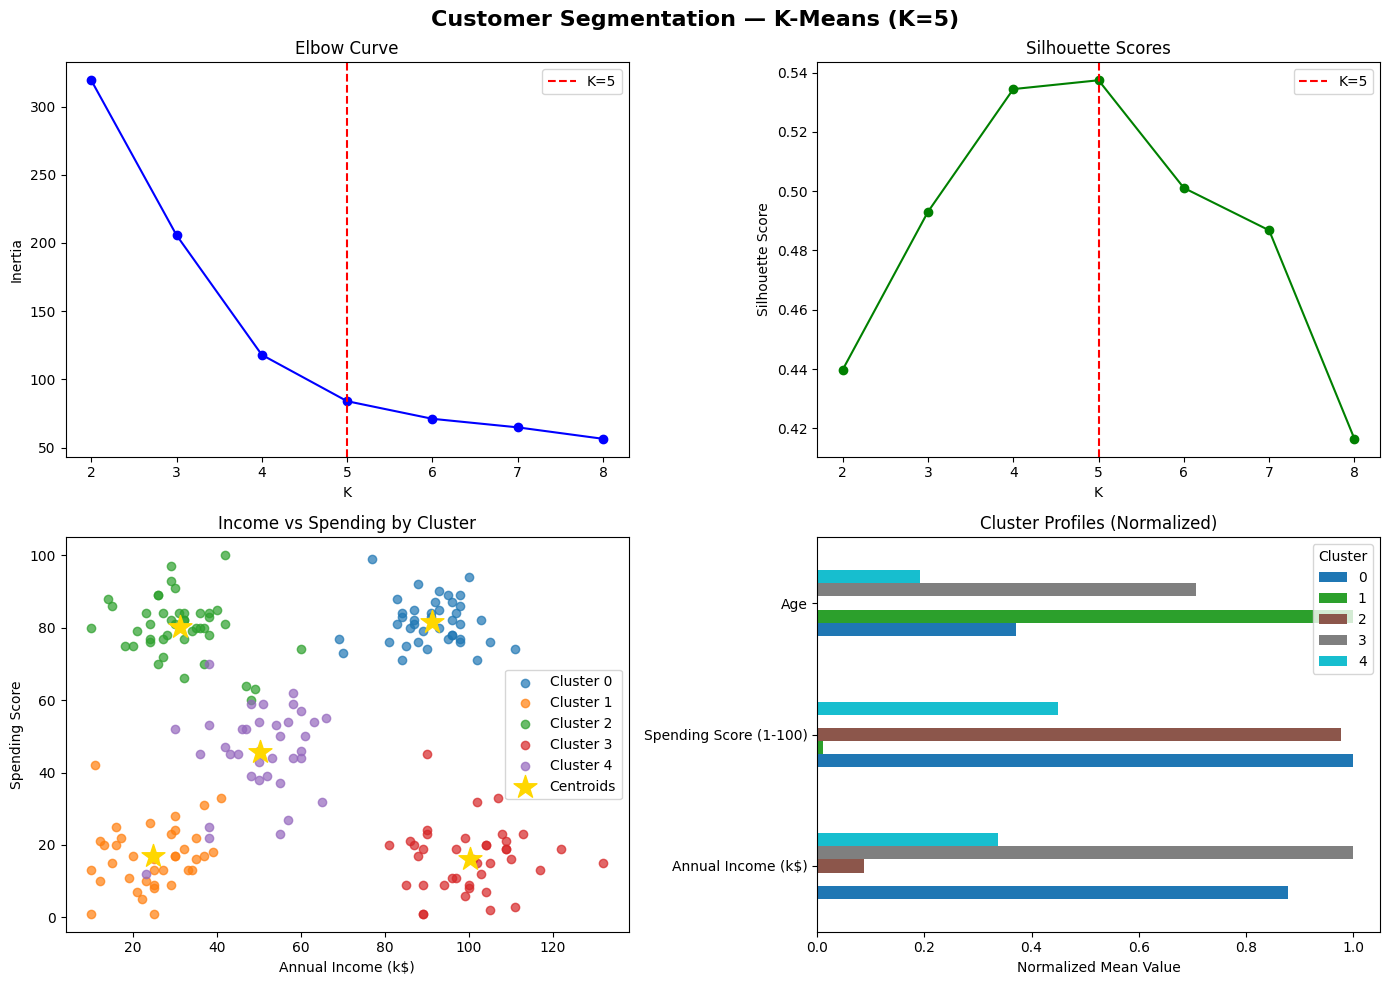

[node] Code executed
[skill] Interpretation done

INTERPRETATION (skill agent):
Based on the clustering analysis, we have identified five distinct customer segments. Here is a detailed interpretation of each segment along with actionable recommendations:

1. **Premium Customers**
   - **Characteristics**: This segment has a high annual income (average of $91.15k) and a high spending score (average of 81.61). The average age is approximately 35 years.
   - **Strategy**: Implement loyalty programs and offer exclusive deals to retain these high-value customers. Consider personalized experiences and premium services to enhance their satisfaction and encourage continued high spending.

2. **Budget Conscious**
   - **Characteristics**: Customers in this segment have a low annual income (average of $24.71k) and a low spending score (average of 16.89). They are generally older, with an average age of 54 years.
   - **Strategy**: Focus on providing discounts and value bundles to attract these c

In [13]:
# ── Run agent ───────────────────────────────────────────────────────────────
print("=" * 60)
print("RUNNING: Agent WITH Skill")
print("=" * 60)

result_skill = skill_graph.invoke({
    "query":            "Perform clustering analysis on this customer dataset to identify customer segments",
    "data_description": get_data_description(df),
    "skill_content":    "",
    "generated_code":   "",
    "execution_output": "",
    "interpretation":   "",
})

print("\n" + "=" * 60)
print("INTERPRETATION (skill agent):")
print("=" * 60)
print(result_skill["interpretation"])

---
## Side-by-Side: Generated Code Comparison

Let's compare what each agent actually produced.

In [14]:
print("=" * 60)
print("CODE — Agent WITHOUT Skill")
print("=" * 60)
print(result_basic["generated_code"])

print("\n" + "=" * 60)
print("CODE — Agent WITH Skill")
print("=" * 60)
print(result_skill["generated_code"])

CODE — Agent WITHOUT Skill
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Assuming df is already loaded
# Selecting features for clustering
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardizing the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Finding the optimal number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plotting the elbow graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Applying KMeans with the optimal number of clusters (let's assume 5 from the elbow method)
kmeans = KMeans(n

---
## Key Takeaways

### What is an Agent Skill?

A **skill file** is a plain Markdown document encoding domain expertise that an agent loads at runtime.
It is **not hardcoded** into the agent — it can be swapped, versioned, and edited by non-engineers.

| Aspect | Without Skill | With Skill |
|--------|-------------|----------|
| K selection | Hardcoded (e.g. K=3) | Elbow + Silhouette search |
| Preprocessing | Often skipped | StandardScaler always applied |
| Visualization | Single scatter | 4-panel dashboard |
| Interpretation | Generic stats | Named segments + recommendations |
| Output quality | Depends on luck | Consistent, repeatable |

### Why This Pattern Matters

- **Reusable:** Same skill file works across different datasets / agents
- **Maintainable:** Domain experts can improve the skill without touching agent code
- **Composable:** Agents can load multiple skills (e.g. `clustering_skill.md` + `visualization_skill.md`)
- **Auditable:** Skill files are human-readable — you can review exactly what knowledge the agent has

### Extending This Pattern

```
clustering_skill.md       → customer segmentation
regression_skill.md       → sales forecasting
anomaly_detection_skill.md → fraud detection
time_series_skill.md      → demand planning
```

The agent picks which skill to load based on the user's query — making it a **skill-routing agent**.